In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('car_data_v4.csv')
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [4]:
df.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [5]:
df1 = df.drop(["Make", "Model", "Color"], axis=1).copy()

In [6]:
df1.head()

,Price,Year,Kilometer,Fuel Type,Transmission,Location,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,505000,2017,87150,Petrol,Manual,Pune,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,450000,2014,75000,Diesel,Manual,Ludhiana,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,220000,2011,67000,Petrol,Manual,Lucknow,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,799000,2019,37500,Petrol,Manual,Mangalore,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,1950000,2018,69000,Diesel,Manual,Mumbai,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [7]:
df1.isna().sum()

,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Owner,0
Seller Type,0
Engine,80
Max Power,80


In [8]:
df1['Engine'] = df1['Engine'].fillna(df1['Engine'].mode()[0])
df1['Max Power'] = df1['Max Power'].fillna(df1['Max Power'].mode()[0])
df1['Max Torque'] = df1['Max Torque'].fillna(df1['Max Torque'].mode()[0])
df1['Drivetrain'] = df1['Drivetrain'].fillna(df1['Drivetrain'].mode()[0])

In [9]:
df1.isna().sum()

,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Owner,0
Seller Type,0
Engine,0
Max Power,0


<Axes: ylabel='Length'>

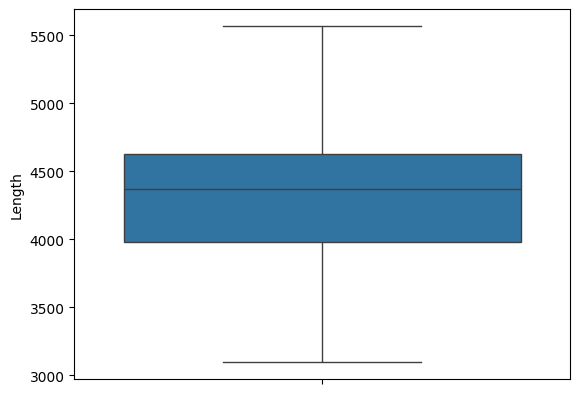

In [10]:
sns.boxplot(df1['Length'])

<Axes: ylabel='Width'>

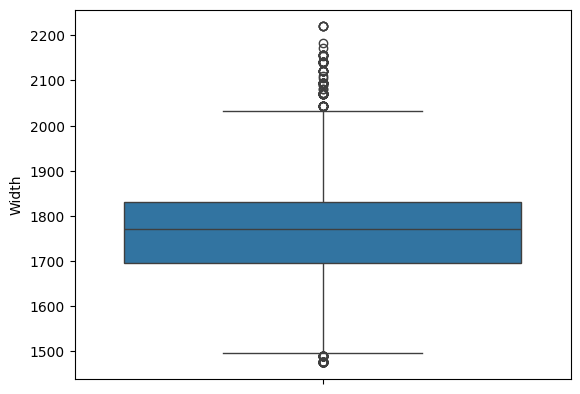

In [11]:
sns.boxplot(df1['Width'])

<Axes: ylabel='Height'>

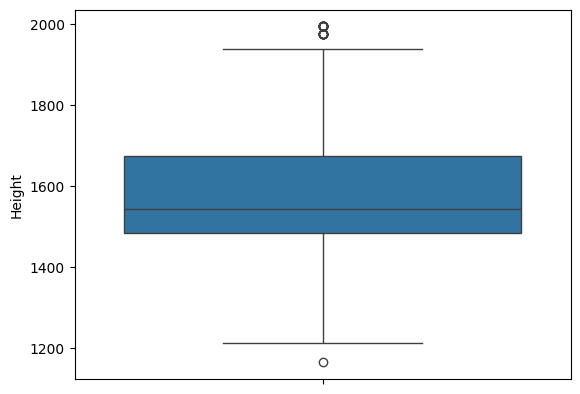

In [12]:
sns.boxplot(df1['Height'])

<Axes: ylabel='Seating Capacity'>

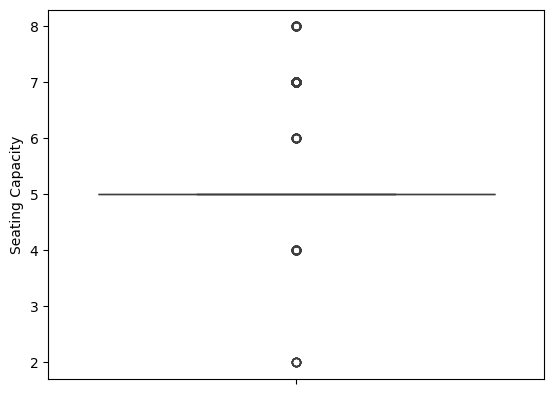

In [13]:
sns.boxplot(df1['Seating Capacity'])

<Axes: ylabel='Fuel Tank Capacity'>

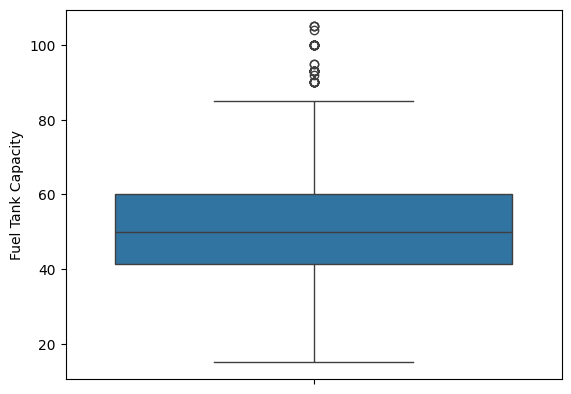

In [14]:
sns.boxplot(df1['Fuel Tank Capacity'])

In [15]:
df1['Length'] = df1['Length'].fillna(df['Length'].mean())
df1['Height'] = df1['Height'].fillna(df['Height'].mean())
df1['Width'] = df1['Width'].fillna(df['Width'].median())
df1['Fuel Tank Capacity'] = df1['Fuel Tank Capacity'].fillna(df['Fuel Tank Capacity'].median())
df1['Seating Capacity'] = df1['Seating Capacity'].fillna(df['Seating Capacity'].median())

In [16]:
df1.isna().sum()

,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Owner,0
Seller Type,0
Engine,0
Max Power,0


In [17]:
object_cols = df1.select_dtypes(include = "object").columns

In [18]:
for col in object_cols:
    print(df1[col].unique())

['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric' 'CNG + CNG' 'Hybrid'
 'Petrol + CNG' 'Petrol + LPG']
['Manual' 'Automatic']
['Pune' 'Ludhiana' 'Lucknow' 'Mangalore' 'Mumbai' 'Coimbatore' 'Bangalore'
 'Delhi' 'Raipur' 'Kanpur' 'Patna' 'Vadodara' 'Hyderabad' 'Yamunanagar'
 'Gurgaon' 'Jaipur' 'Deoghar' 'Agra' 'Goa' 'Warangal' 'Jalandhar' 'Noida'
 'Ahmedabad' 'Mohali' 'Navi Mumbai' 'Ghaziabad' 'Kolkata' 'Zirakpur'
 'Nagpur' 'Thane' 'Faridabad' 'Ranchi' 'Chandigarh' 'Amritsar' 'Chennai'
 'Udupi' 'Panvel' 'Jamshedpur' 'Aurangabad' 'Rudrapur' 'Nashik' 'Varanasi'
 'Salem' 'Dehradun' 'Valsad' 'Haldwani' 'Dharwad' 'Surat' 'Indore'
 'Karnal' 'Panchkula' 'Mysore' 'Rohtak' 'Ambala Cantt' 'Samastipur'
 'Unnao' 'Purnea' 'Bhubaneswar' 'Kheda' 'Kollam' 'Meerut' 'Ernakulam'
 'Kharar' 'Mirzapur' 'Bhopal' 'Gorakhpur' 'Guwahati' 'Allahabad'
 'Muzaffurpur' 'Faizabad' 'Kota' 'Pimpri-Chinchwad' 'Dak. Kannada'
 'Ranga Reddy' 'Bulandshahar' 'Roorkee' 'Siliguri']
['First' 'Second' 'Third' 'Fourth' 'UnRegistered Car' '

In [19]:
df1["Fuel Type"].value_counts()

,count
Fuel Type,
Diesel,1049
Petrol,942
CNG,50
Electric,7
LPG,5
Hybrid,3
CNG + CNG,1
Petrol + CNG,1
Petrol + LPG,1


In [20]:
df1["Fuel Type"] = df1['Fuel Type'].replace("CNG + CNG", "CNG")
df1["Fuel Type"] = df1['Fuel Type'].replace("Petrol + CNG", "Petrol + Gas")
df1["Fuel Type"] = df1['Fuel Type'].replace("Petrol + LPG", "Petrol + Gas")

In [21]:
df1['Fuel Type'].value_counts()

,count
Fuel Type,
Diesel,1049
Petrol,942
CNG,51
Electric,7
LPG,5
Hybrid,3
Petrol + Gas,2


In [22]:
location_counts = df1['Location'].value_counts()
locations_with_count = location_counts[location_counts <= 100]
df1['Location'] = df1['Location'].replace(locations_with_count.index.tolist(), 'Others')

# Display the updated value counts for 'Location' to verify the change
print("Updated value counts for Location after replacing with 'Others':")
print(df1['Location'].value_counts())


Updated value counts for Location after replacing with 'Others':
Location
Others       1018
Mumbai        342
Delhi         307
Pune          144
Bangalore     132
Hyderabad     116
Name: count, dtype: int64


In [23]:
price_by_location = df1.groupby('Location')['Price'].mean()
price_by_location.sort_values(ascending=False)

,Price
Location,
Delhi,2.585111e+06
Hyderabad,2.079776e+06
Bangalore,2.028720e+06
Pune,1.977764e+06
Mumbai,1.721570e+06
Others,1.306691e+06


In [24]:
## Apply oridinal encoding to the location column

In [25]:
price_by_owner_type = df1.groupby(['Owner', 'Seller Type'])['Price'].mean()
price_by_owner_type.sort_values(ascending=False)

,,Price
Owner,Seller Type,
Second,Corporate,5.480000e+06
UnRegistered Car,Individual,5.285333e+06
First,Corporate,2.852173e+06
Third,Individual,1.981929e+06
First,Individual,1.680100e+06
Second,Individual,1.383133e+06
First,Commercial Registration,5.190000e+05
Fourth,Individual,1.633333e+05
4 or More,Individual,1.200000e+05


In [26]:
for col in object_cols:
    print(df1[col].unique())

['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric' 'Hybrid' 'Petrol + Gas']
['Manual' 'Automatic']
['Pune' 'Others' 'Mumbai' 'Bangalore' 'Delhi' 'Hyderabad']
['First' 'Second' 'Third' 'Fourth' 'UnRegistered Car' '4 or More']
['Corporate' 'Individual' 'Commercial Registration']
['1198 cc' '1248 cc' '1197 cc' '2393 cc' '1373 cc' '1991 cc' '1995 cc'
 '1798 cc' '1461 cc' '999 cc' '1462 cc' '1956 cc' '998 cc' '796 cc'
 '1591 cc' '1086 cc' '1199 cc' '1582 cc' '1047 cc' '2143 cc' '1968 cc'
 '1796 cc' '2498 cc' '2494 cc' '2179 cc' '1998 cc' '1497 cc' '1196 cc'
 '2755 cc' '1799 cc' '1493 cc' '1399 cc' '1498 cc' '1997 cc' '1598 cc'
 '2993 cc' '2995 cc' '2982 cc' '1353 cc' '1984 cc' '2967 cc' '2609 cc'
 '1950 cc' '1999 cc' '4663 cc' '1451 cc' '2354 cc' '1396 cc' '2987 cc'
 '2997 cc' '1336 cc' '4163 cc' '3496 cc' '799 cc' '2979 cc' '4806 cc'
 '2996 cc' '1061 cc' '2184 cc' '2497 cc' '2999 cc' '1948 cc' '3436 cc'
 '2925 cc' '2489 cc' '1368 cc' '1797 cc' '1298 cc' '2694 cc' '1186 cc'
 '1364 cc' '3498 cc' '398

In [27]:
df1["Owner"].value_counts()

,count
Owner,
First,1619
Second,373
Third,42
UnRegistered Car,21
Fourth,3
4 or More,1


In [28]:
df1["Owner"] = df1['Owner'].replace("Fourth", "Other")
df1["Owner"] = df1['Owner'].replace("Third", "Other")
df1["Owner"] = df1['Owner'].replace("4 or More", "Other")
df1["Owner"] = df1['Owner'].replace("UnRegistered Car", "Other")

In [29]:
df1['Owner'].value_counts()

,count
Owner,
First,1619
Second,373
Other,67


In [30]:
object_cols

Index(['Fuel Type', 'Transmission', 'Location', 'Owner', 'Seller Type',
       'Engine', 'Max Power', 'Max Torque', 'Drivetrain'],
      dtype='object')

In [31]:
df2 = df1.copy()

In [32]:
df2[['Engine', 'Max Power', 'Max Torque']]

,Engine,Max Power,Max Torque
0,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm
1,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm
2,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm
3,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm
4,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm
...,...,...,...
2054,2179 cc,138 bhp @ 3750 rpm,330 Nm @ 1600 rpm
2055,814 cc,55 bhp @ 5500 rpm,75 Nm @ 4000 rpm
2056,1196 cc,70 bhp @ 6250 rpm,102 Nm @ 4000 rpm
2057,1995 cc,188 bhp @ 4000 rpm,400 Nm @ 1750 rpm


In [35]:
df2['Fuel Type'].unique()

array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric', 'Hybrid',
       'Petrol + Gas'], dtype=object)

In [36]:
values_to_change = ['CNG', 'LPG', 'Electric', 'Hybrid',
       'Petrol + Gas']
df2['Fuel Type'] = df2['Fuel Type'].replace(values_to_change, "Other")

In [37]:
df2['Fuel Type'].value_counts()

,count
Fuel Type,
Diesel,1049
Petrol,942
Other,68


In [40]:
for col in object_cols:
    print(df2[col].unique())
    print("-" * 30)

['Petrol' 'Diesel' 'Other']
------------------------------
['Manual' 'Automatic']
------------------------------
['Pune' 'Others' 'Mumbai' 'Bangalore' 'Delhi' 'Hyderabad']
------------------------------
['First' 'Second' 'Other']
------------------------------
['Corporate' 'Individual' 'Commercial Registration']
------------------------------
['1198 cc' '1248 cc' '1197 cc' '2393 cc' '1373 cc' '1991 cc' '1995 cc'
 '1798 cc' '1461 cc' '999 cc' '1462 cc' '1956 cc' '998 cc' '796 cc'
 '1591 cc' '1086 cc' '1199 cc' '1582 cc' '1047 cc' '2143 cc' '1968 cc'
 '1796 cc' '2498 cc' '2494 cc' '2179 cc' '1998 cc' '1497 cc' '1196 cc'
 '2755 cc' '1799 cc' '1493 cc' '1399 cc' '1498 cc' '1997 cc' '1598 cc'
 '2993 cc' '2995 cc' '2982 cc' '1353 cc' '1984 cc' '2967 cc' '2609 cc'
 '1950 cc' '1999 cc' '4663 cc' '1451 cc' '2354 cc' '1396 cc' '2987 cc'
 '2997 cc' '1336 cc' '4163 cc' '3496 cc' '799 cc' '2979 cc' '4806 cc'
 '2996 cc' '1061 cc' '2184 cc' '2497 cc' '2999 cc' '1948 cc' '3436 cc'
 '2925 cc' '2489 cc'

In [47]:
df2["Engine"] = df2["Engine"].str.split(" ").str[0]

In [48]:
df2['Engine'] = df2["Engine"].astype("int64")

In [58]:
df2["Max Power"] = df2["Max Power"].str.split("@").str[0].str.split("b").str[0].astype("float64")

In [61]:
df2["Max Power"].unique()

array([ 87. ,  74. ,  79. ,  82. , 148. ,  91. , 181. , 188. , 177. ,
        84. ,  67. , 103. , 138. ,  47. , 122. ,  68. , 118. ,  58. ,
        85. ,  89. , 126. , 124. ,  62. ,  69. , 168. , 203. , 165. ,
       105. ,  83. , 169. , 101. , 190. , 171. , 120. , 117. ,  73. ,
       184. , 174. , 130. ,  99. , 141. , 179. , 150. , 207. , 170. ,
       202. , 108. , 258. , 335. , 241. , 121. , 115. , 204. , 104. ,
        63. ,  81. , 245. , 116. , 248. , 113. , 192. , 201. , 453. ,
       152. , 153. , 134. ,  75. , 102. , 234. , 186. , 231. , 254. ,
       109. , 444. , 272. ,  53. , 180. , 140. , 172. , 275. , 500. ,
       362. , 296. ,  80. , 255. ,  90. , 325. , 282. ,  95. , 160. ,
       262. , 147. , 119. , 164. , 208. , 136. , 114. ,  70. , 463. ,
        71. ,  59. , 154. , 112. , 295. , 100. , 660. ,  35. , 176. ,
       197. , 602. ,  55. , 182. , 326. , 215. , 368. , 194. , 244. ,
        56. , 128. , 189. ,  76. , 157. ,  94. , 289. , 142. , 178. ,
        64. , 218. ,

In [74]:
df2["Torque"] = df2["Max Torque"].str.split("@").str[0].str.split(" ").str[0].astype("float64")

In [84]:
df2["RPM"] = df2["Max Torque"].str.split("@").str[1].str.split(" ").str[1].astype("float64")

In [85]:
df2.head()

,Price,Year,Kilometer,Fuel Type,Transmission,Location,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Torque,RPM
0,505000,2017,87150,Petrol,Manual,Pune,First,Corporate,1198,87.0,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0,109.0000,4500.0
1,450000,2014,75000,Diesel,Manual,Others,Second,Individual,1248,74.0,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0,190.0000,2000.0
2,220000,2011,67000,Petrol,Manual,Others,First,Individual,1197,79.0,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0,112.7619,4000.0
3,799000,2019,37500,Petrol,Manual,Others,First,Individual,1197,82.0,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0,113.0000,4200.0
4,1950000,2018,69000,Diesel,Manual,Mumbai,First,Individual,2393,148.0,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0,343.0000,1400.0


In [86]:
df2.drop("Max Torque", axis = 1, inplace = True)

In [87]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Price               2059 non-null   int64  
 1   Year                2059 non-null   int64  
 2   Kilometer           2059 non-null   int64  
 3   Fuel Type           2059 non-null   object 
 4   Transmission        2059 non-null   object 
 5   Location            2059 non-null   object 
 6   Owner               2059 non-null   object 
 7   Seller Type         2059 non-null   object 
 8   Engine              2059 non-null   int64  
 9   Max Power           2059 non-null   float64
 10  Drivetrain          2059 non-null   object 
 11  Length              2059 non-null   float64
 12  Width               2059 non-null   float64
 13  Height              2059 non-null   float64
 14  Seating Capacity    2059 non-null   float64
 15  Fuel Tank Capacity  2059 non-null   float64
 16  Torque

<Axes: ylabel='RPM'>

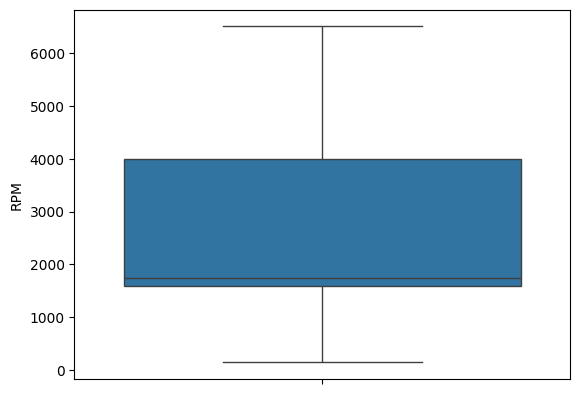

In [89]:
import seaborn as sns
sns.boxplot(df2['RPM'])

In [90]:
## Filling with mean
df2["RPM"] = df2["RPM"].fillna(df2["RPM"].mean())

In [91]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Price               2059 non-null   int64  
 1   Year                2059 non-null   int64  
 2   Kilometer           2059 non-null   int64  
 3   Fuel Type           2059 non-null   object 
 4   Transmission        2059 non-null   object 
 5   Location            2059 non-null   object 
 6   Owner               2059 non-null   object 
 7   Seller Type         2059 non-null   object 
 8   Engine              2059 non-null   int64  
 9   Max Power           2059 non-null   float64
 10  Drivetrain          2059 non-null   object 
 11  Length              2059 non-null   float64
 12  Width               2059 non-null   float64
 13  Height              2059 non-null   float64
 14  Seating Capacity    2059 non-null   float64
 15  Fuel Tank Capacity  2059 non-null   float64
 16  Torque

In [95]:
df2["Transmission"] = df2["Transmission"].map({"Manual" : 0, "Automatic" : 1})

In [98]:
df2["Owner"] = df2["Owner"].map({"Other" : 0, "Second" : 1, "First" : 2})

In [99]:
object_cols = df2.select_dtypes(include="object").columns
num_cols = df2.select_dtypes(exclude="object").columns

In [100]:
object_cols

Index(['Fuel Type', 'Location', 'Seller Type', 'Drivetrain'], dtype='object')

In [102]:
num_cols

Index(['Price', 'Year', 'Kilometer', 'Transmission', 'Owner', 'Engine',
       'Max Power', 'Length', 'Width', 'Height', 'Seating Capacity',
       'Fuel Tank Capacity', 'Torque', 'RPM'],
      dtype='object')

In [103]:
## Spliting the dataset
X = df2.drop('Price', axis = 1)
y = df2["Price"]

In [107]:
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

In [108]:
num_cols

Index(['Year', 'Kilometer', 'Transmission', 'Owner', 'Engine', 'Max Power',
       'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity',
       'Torque', 'RPM'],
      dtype='object')

In [109]:
cat_cols

Index(['Fuel Type', 'Location', 'Seller Type', 'Drivetrain'], dtype='object')

In [104]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [106]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1647, 17), (1647,), (412, 17), (412,))

In [112]:
# Encodding
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_pipeline = Pipeline(
    steps = [
        ("scaler", StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps=[
        ("Encoder", OneHotEncoder(handle_unknown="ignore", drop = "first", sparse_output=False)),
        ("Scaler", StandardScaler()) # Instantiate StandardScaler here
    ]
)

preprocessor = ColumnTransformer(transformers=[
    ("scaler", num_pipeline, num_cols),
    ("oh_encoder", cat_pipeline, cat_cols)
], remainder="passthrough"
)

In [113]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [115]:
X_train_scaled.shape

(1647, 24)

In [116]:
## Model Creation
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

In [118]:
models = {
    "DecisionTree" : DecisionTreeRegressor(),
    "RandomForest" : RandomForestRegressor(),
    "Adaboost" : AdaBoostRegressor(),
    "GradientBoost" : GradientBoostingRegressor(),
    "Xgboost" : XGBRegressor()
}
models

{'DecisionTree': DecisionTreeRegressor(),
 'RandomForest': RandomForestRegressor(),
 'Adaboost': AdaBoostRegressor(),
 'GradientBoost': GradientBoostingRegressor(),
 'Xgboost': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)}

In [120]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scaled, y_train)
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    print(f"{list(models.keys())[i]} training accuracy : {r2_score(y_train, y_pred_train) * 100}")
    print(f"{list(models.keys())[i]} testing accuracy : {r2_score(y_test, y_pred_test) * 100}")
    print("-"*30)

DecisionTree training accuracy : 99.98379472635239
DecisionTree testing accuracy : 78.74665101452891
------------------------------
RandomForest training accuracy : 98.1565429013138
RandomForest testing accuracy : 82.81780851350922
------------------------------
Adaboost training accuracy : 68.57199563577043
Adaboost testing accuracy : 64.7546954841437
------------------------------
GradientBoost training accuracy : 97.32695613112156
GradientBoost testing accuracy : 89.0097856840322
------------------------------
Xgboost training accuracy : 99.92426633834839
Xgboost testing accuracy : 86.51437163352966
------------------------------


## GradientBoost is the best performing model with a accuracy of 89%.